# Degradation-Mode Engine — Validation Study

**Question:** can periodic 0.5C diagnostic cycles support honest LLI / LAM_pe / LAM_ne attribution on
Tesla-relevant chemistries (NCA, NMC), while quantifying why LFP diagnostics are muted?

Dataset: Sandia/SNL 61 commercial 18650 cells (22 NCA Panasonic NCR18650B / 21 NMC LG HG2 / 18 LFP A123)
via the BatteryLife processed mirror. Preger et al. 2020 J. Electrochem. Soc.; double-attribution license.

| Check | Pass criterion |
|---|---|
| Fade closure | median cap-reconstruction error <= 3% nominal for >= 80% of NCA+NMC cells |
| Mode sanity | dominant mode Spearman rho >= 0.8 for >= 70% of NCA+NMC cells |
| Chemistry contrast | NCA/NMC voltage dispersion >= 3x LFP |
| Condition systematics | >= 2 known Preger trends reproduced |

Decision rule (the study plan): BUILD if all four pass; RESCOPE to ICA-tracking-only if closure or
sanity fails but contrast holds; KILL mode attribution if fits are unstable across the board.

In [1]:
import sys, pathlib, pickle
sys.path.insert(0, str(pathlib.Path().resolve().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.snl_data import load_snl, load_cell
from src.dva import dqdv, dvdq, ica_peak_stats, voltage_dispersion
from src.modes import fit_cell_trajectory
from src.gate_modes import evaluate_cell, gate_checks, decide_p1

ROOT = pathlib.Path().resolve().parent
FIG_DIR = ROOT / 'figures'
FIG_DIR.mkdir(exist_ok=True)
np.random.seed(0)

## 1. Load the SNL fleet (verify schema on one cell first)

In [2]:
cells = load_snl(str(ROOT / 'data/snl/SNL'), verbose=False)
print(f"{len(cells)} cells")
one = cells['SNL_18650_NCA_25C_0-100_0.5-1C_a']
print({k: v for k, v in one.items() if k not in ('fade', 'diagnostics')})
print('fade series len:', len(one['fade'][0]), ' diagnostics:', len(one['diagnostics']))
q, v = one['diagnostics'][0]['charge']
print('diag charge segment:', len(q), 'pts, Q to', round(q[-1], 2), 'Ah, V', round(v[0], 2), '->', round(v[-1], 2))
chem_counts = pd.Series([c['chemistry'] for c in cells.values()]).value_counts()
print(chem_counts.to_dict())

61 cells
{'cell_id': 'SNL_18650_NCA_25C_0-100_0.5-1C_a', 'chemistry': 'NCA', 'temperature_C': 25, 'dod_lo': 0, 'dod_hi': 100, 'charge_rate_C': 0.5, 'discharge_rate_C': 1.0, 'replicate': 'a', 'nominal_capacity_Ah': 3.2}
fade series len: 654  diagnostics: 13
diag charge segment: 536 pts, Q to 2.26 Ah, V 2.77 -> 4.2
{'NCA': 22, 'NMC': 21, 'LFP': 18}


## 2. The chemistry story in one figure

ICA (dQ/dV) of fresh vs aged diagnostics per chemistry. NCA/NMC spread charge over a wide,
featured voltage range; LFP compresses everything into a ~0.15 V band — that is the
'muted diagnostics' problem, quantified below as voltage dispersion.

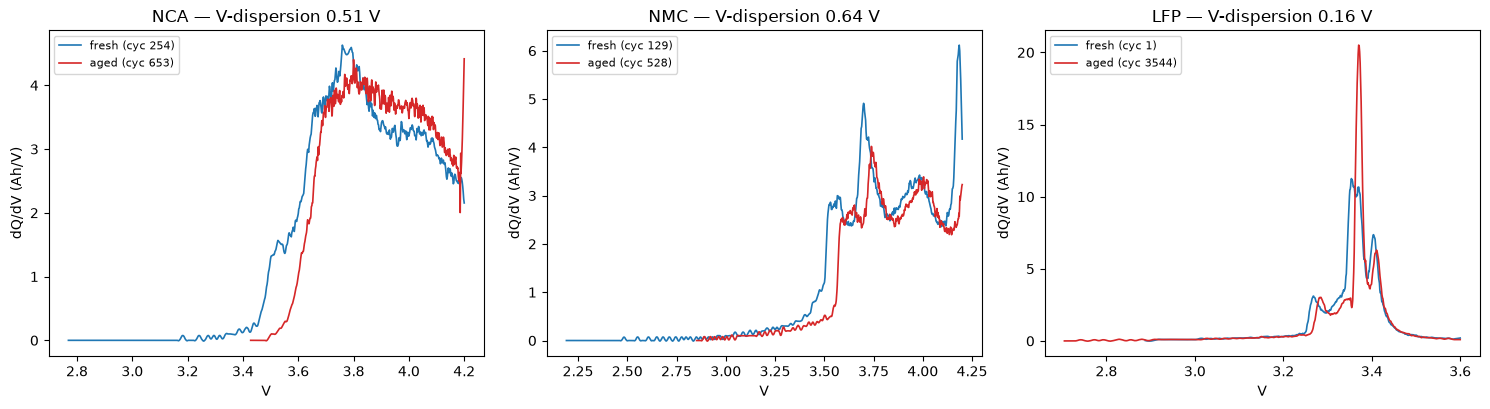

In [3]:
EXAMPLES = {'NCA': 'SNL_18650_NCA_25C_0-100_0.5-1C_a',
            'NMC': 'SNL_18650_NMC_25C_0-100_0.5-1C_d',
            'LFP': 'SNL_18650_LFP_25C_0-100_0.5-1C_a'}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, (chem, cid) in zip(axes, EXAMPLES.items()):
    cell = cells[cid]
    diags = [d for d in cell['diagnostics'] if 'charge' in d]
    for d, color, lbl in [(diags[0], 'tab:blue', 'fresh'), (diags[-1], 'tab:red', 'aged')]:
        vg, ic = dqdv(*d['charge'])
        ax.plot(vg, ic, color=color, lw=1.2, label=f"{lbl} (cyc {d['cycle_number']})")
    disp = voltage_dispersion(*diags[0]['charge'])
    ax.set_title(f"{chem} — V-dispersion {disp:.2f} V")
    ax.set_xlabel('V'); ax.set_ylabel('dQ/dV (Ah/V)'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_ica_chemistry.png', dpi=150)
plt.show()

## 3. Mode attribution — Dahn-style electrode alignment (src/modes.py)

Per diagnostic cycle: fit V(Q) = U_pe(y0 - Q/C_pe) - U_ne(x0 + Q/C_ne) + eta with cited half-cell
references (NCA: Kim2011; NMC811: Chen2020; LFP: Afshar2017; graphite: Ecker2015), joint V + dV/dQ
residuals, an endpoint-capacity consistency term, and a continuity prior along the trajectory
(the problem is multimodal; unregularized fits hop between local-minimum families).

Example trajectories: the NMC success case and the NCA problem case.

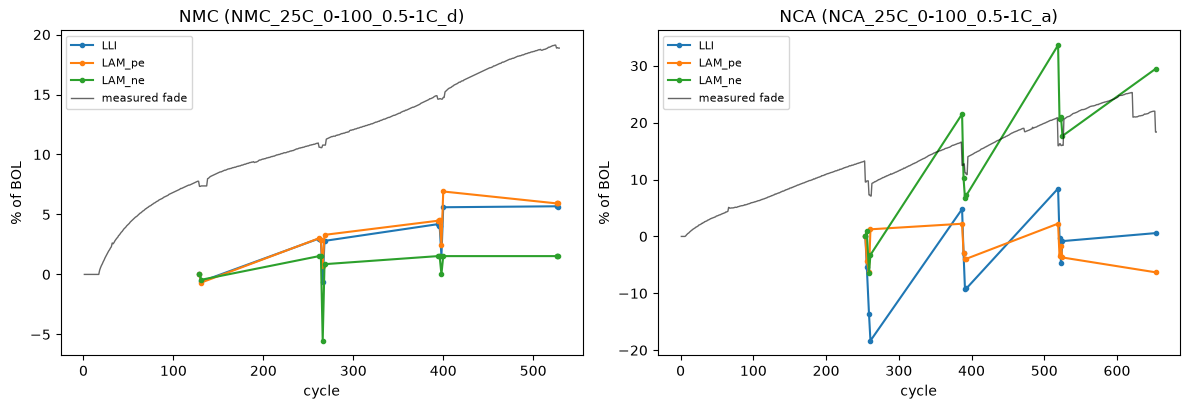

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, chem in zip(axes, ['NMC', 'NCA']):
    df = fit_cell_trajectory(cells[EXAMPLES[chem]])
    for mode, color in [('LLI', 'tab:blue'), ('LAM_pe', 'tab:orange'), ('LAM_ne', 'tab:green')]:
        ax.plot(df.index, 100 * df[mode], 'o-', color=color, ms=3, label=mode)
    cyc, qd = cells[EXAMPLES[chem]]['fade']
    ax.plot(cyc, 100 * (1 - qd / qd[0]), 'k-', lw=1, alpha=0.6, label='measured fade')
    ax.set_title(f"{chem} ({EXAMPLES[chem].split('SNL_18650_')[1]})")
    ax.set_xlabel('cycle'); ax.set_ylabel('% of BOL'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_mode_trajectories.png', dpi=150)
plt.show()

## 4. Fleet evaluation — all 61 cells

Uses the cached results if present (`data/p1_fleet_results.pkl`); delete the cache to recompute
from scratch (~5 min).

In [5]:
cache = ROOT / 'data/p1_fleet_results.pkl'
if cache.exists():
    saved = pickle.load(open(cache, 'rb'))
    fleet, trajs = saved['fleet'], saved['trajs']
else:
    rows, trajs = [], {}
    for cid, cell in cells.items():
        out, df = evaluate_cell(cell)
        rows.append(out); trajs[cid] = df
    fleet = pd.DataFrame(rows).set_index('cell_id')
    pickle.dump({'fleet': fleet, 'trajs': trajs}, open(cache, 'wb'))
print(f"{len(fleet)} cells evaluated")
display(fleet.groupby('chemistry')[['rmse_mV_med', 'closure_med', 'rho_dominant',
                                    'v_dispersion', 'fade_frac']].median().round(3))

61 cells evaluated


,rmse_mV_med,closure_med,rho_dominant,v_dispersion,fade_frac
chemistry,,,,,
LFP,15.679,0.033,0.754,0.148,0.148
NCA,5.406,0.015,0.712,0.514,0.248
NMC,9.845,0.015,0.754,0.594,0.181


### Per-chemistry detail: where attribution holds and where it breaks

In [6]:
for chem in ['NCA', 'NMC', 'LFP']:
    sub = fleet[fleet['chemistry'] == chem]
    ok_rho = (sub['rho_dominant'] >= 0.8).mean()
    ok_clo = (sub['closure_med'] <= 0.03).mean()
    print(f"{chem}: n={len(sub):2d}  rho>=0.8: {ok_rho:.0%}  closure<=3%: {ok_clo:.0%}  "
          f"dominant modes: {sub['dominant_mode'].value_counts().to_dict()}")

NCA: n=22  rho>=0.8: 36%  closure<=3%: 100%  dominant modes: {'LAM_ne': 9, 'LAM_pe': 9, 'LLI': 4}
NMC: n=21  rho>=0.8: 38%  closure<=3%: 100%  dominant modes: {'LAM_pe': 12, 'LLI': 6, 'LAM_ne': 3}
LFP: n=18  rho>=0.8: 22%  closure<=3%: 28%  dominant modes: {'LAM_pe': 12, 'LLI': 6}


## 5. Condition systematics (attribution-independent, from measured fade)

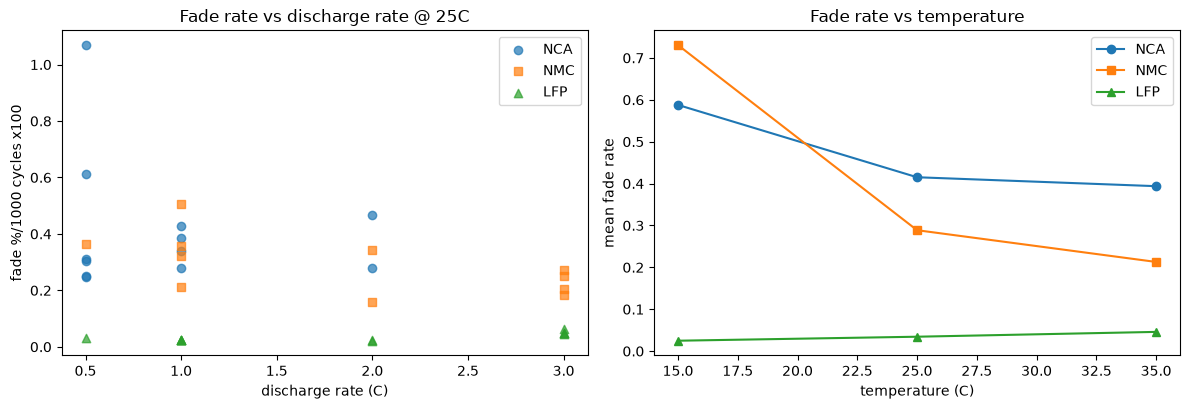

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for chem, marker in [('NCA', 'o'), ('NMC', 's'), ('LFP', '^')]:
    sub = fleet[(fleet['chemistry'] == chem) & (fleet['temperature_C'] == 25)]
    axes[0].scatter(sub['discharge_rate_C'], sub['fade_per_kcycle'], marker=marker, label=chem, alpha=0.7)
    subT = fleet[fleet['chemistry'] == chem].groupby('temperature_C')['fade_per_kcycle'].mean()
    axes[1].plot(subT.index, subT.values, marker + '-', label=chem)
axes[0].set_xlabel('discharge rate (C)'); axes[0].set_ylabel('fade %/1000 cycles x100')
axes[0].set_title('Fade rate vs discharge rate @ 25C'); axes[0].legend()
axes[1].set_xlabel('temperature (C)'); axes[1].set_ylabel('mean fade rate')
axes[1].set_title('Fade rate vs temperature'); axes[1].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'p1_systematics.png', dpi=150)
plt.show()

## 6. Gate decision

In [8]:
checks = gate_checks(fleet)
decision = decide_p1(checks)
W = 60
print('=' * W)
print(f"{'DIAGNOSTICS STUDY RESULT':^{W}s}")
print('=' * W)
for name, c in checks.items():
    detail = {k: (round(v, 3) if isinstance(v, float) else v)
              for k, v in c.items() if k != 'pass'}
    print(f"  {name:<24s} {'PASS' if c['pass'] else 'FAIL':>6s}  {detail}")
print('-' * W)
print(f"{'DECISION:':<24s}{decision:>10s}")
print('=' * W)

                    DIAGNOSTICS STUDY RESULT                     
  fade_closure               PASS  {'frac_ok': 1.0, 'need': 0.8}
  mode_sanity                FAIL  {'frac_ok': 0.372, 'need': 0.7}
  chemistry_contrast         PASS  {'ratio': 3.25, 'need': 3.0}
  condition_systematics      PASS  {'lfp_35C_vs_15C': 3.327, 'nca_rate_fade_rho': 0.565, 'nmc_temp_fade_rho': -0.752, 'n_confirmed': 2}
------------------------------------------------------------
DECISION:                  RESCOPE
